In [56]:
import pandas as  pd
import numpy as np 
import matplotlib.pyplot as plt

In [57]:
transaction = pd.read_csv("D:/DA_Project/Quantium_Virtual_Internship/notebook/QVI_transaction_data.csv")
customer = pd.read_csv("D:/DA_Project/Quantium_Virtual_Internship/notebook/QVI_purchase_behaviour.csv")

In [58]:
# data Understanding & Cleaning 
# Check structure

transaction.info()
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [59]:
# check any null values 
transaction.isnull().sum()
customer.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [60]:
# check duplicates 
transaction.duplicated().sum()
customer.duplicated().sum()

np.int64(0)

In [61]:
# check date column
transaction['DATE'].head()

0    43390
1    43599
2    43605
3    43329
4    43330
Name: DATE, dtype: int64

In [62]:
# convert date to proper formate 
transaction['DATE'] =pd.to_datetime(transaction['DATE'] , origin='1899-12-30' ,unit='D')


In [63]:
transaction['DATE'].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[s]

In [64]:
# Check for outliers
# determine if packet sizes are relevant
transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [65]:
transaction.columns


Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='str')

In [66]:
# Extract PACK SIZE from product name

transaction['PACK_SIZE'] = transaction['PROD_NAME'].str.extract('(\d+)').astype(int)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\User\AppData\Local\Temp\ipykernel_8824\1021162203.py:3: SyntaxWarning: invalid escape sequence '\d'
  transaction['PACK_SIZE'] = transaction['PROD_NAME'].str.extract('(\d+)').astype(int)


In [67]:
transaction[['PROD_NAME' , 'PACK_SIZE']].head()

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150


In [68]:
# Extract BRAND NAME to identify trends, sales drivers, and customer behaviour


transaction['BRAND'] = transaction['PROD_NAME'].str.split().str[0]
transaction[['PROD_NAME' ,'BRAND']].head()

,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle


In [69]:
# Merge Transaction + Customer Data to analyze customer segments and their purchasing behaviour .

data = pd.merge(transaction , customer , on='LYLTY_CARD_NBR', how='left')

In [70]:
# quick check 
data[['LYLTY_CARD_NBR','LIFESTAGE','PREMIUM_CUSTOMER']].head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1307,MIDAGE SINGLES/COUPLES,Budget
2,1343,MIDAGE SINGLES/COUPLES,Budget
3,2373,MIDAGE SINGLES/COUPLES,Budget
4,2426,MIDAGE SINGLES/COUPLES,Budget


In [71]:
data.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='str')

In [72]:
data['TOT_SALES'].sum()

np.float64(1934415.0)

In [73]:
# Sales by Customer Segment identify customer segments and their purchasing behaviour
data.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)

LIFESTAGE
OLDER SINGLES/COUPLES     402426.75
RETIREES                  366470.90
OLDER FAMILIES            353767.20
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
Name: TOT_SALES, dtype: float64

In [74]:
data.groupby('LIFESTAGE')['LYLTY_CARD_NBR'].nunique().sort_values(ascending=False)

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: LYLTY_CARD_NBR, dtype: int64

In [75]:
# Average spend per customer Which segment is most valuable per customer 
sales_per_coustomer = data.groupby('LIFESTAGE').agg({
    'TOT_SALES' :'sum',
    'LYLTY_CARD_NBR':'nunique'

})

# Average Spend = Total Sales ÷ Number of Customers
sales_per_coustomer['AVG_SPEND'] = sales_per_coustomer['TOT_SALES'] / sales_per_coustomer['LYLTY_CARD_NBR']

sales_per_coustomer.sort_values('AVG_SPEND', ascending=False)


,TOT_SALES,LYLTY_CARD_NBR,AVG_SPEND
LIFESTAGE,,,
OLDER FAMILIES,353767.20,9780,36.172515
YOUNG FAMILIES,316160.10,9178,34.447603
OLDER SINGLES/COUPLES,402426.75,14609,27.546495
MIDAGE SINGLES/COUPLES,184751.30,7275,25.395368
RETIREES,366470.90,14805,24.753185
NEW FAMILIES,50433.45,2549,19.785583
YOUNG SINGLES/COUPLES,260405.30,14441,18.032359


In [76]:
qty_per_customer = data.groupby('LIFESTAGE').agg({
  'PROD_QTY' :'sum',
  'LYLTY_CARD_NBR':'nunique' })

qty_per_customer['AVG_QTY'] = qty_per_customer['PROD_QTY'] / sales_per_coustomer['LYLTY_CARD_NBR']

qty_per_customer.sort_values('AVG_QTY' ,ascending=False)


,PROD_QTY,LYLTY_CARD_NBR,AVG_QTY
LIFESTAGE,,,
OLDER FAMILIES,94992,9780,9.712883
YOUNG FAMILIES,84561,9178,9.213445
OLDER SINGLES/COUPLES,104203,14609,7.132795
MIDAGE SINGLES/COUPLES,47721,7275,6.559588
RETIREES,94166,14805,6.360419
NEW FAMILIES,12847,2549,5.040016
YOUNG SINGLES/COUPLES,66634,14441,4.614223


In [77]:
data.groupby('PACK_SIZE')['TOT_SALES'].sum().sort_values(ascending=False)

PACK_SIZE
175    485437.4
150    304288.5
134    177655.5
110    162765.4
170    146673.0
330    136794.3
300    113330.6
165    101360.6
380     76719.6
270     55425.4
210     43048.8
250     26096.7
135     26090.4
200     16007.5
190     14412.9
160     10647.6
90       9676.4
180      8568.4
70       6852.0
220      6831.0
125      5733.0
Name: TOT_SALES, dtype: float64

In [78]:
data.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False)

BRAND
Kettle        390239.8
Smiths        210076.8
Doritos       201538.9
Pringles      177655.5
Old            90785.1
Thins          88852.5
Twisties       81522.1
Tostitos       79789.6
Infuzions      76247.6
Cobs           70569.8
RRD            64954.5
Tyrrells       51647.4
Grain          43048.8
Dorito         40352.0
Cheezels       40029.9
WW             35889.5
Natural        34272.0
Red            30091.5
Infzns         22800.0
CCs            18078.9
Cheetos        16884.5
Smith          14583.4
Woolworths     13454.1
GrnWves         8568.4
NCC             8046.0
French          7929.0
Burger          6831.0
Snbts           5076.2
Sunbites        4600.2
Name: TOT_SALES, dtype: float64

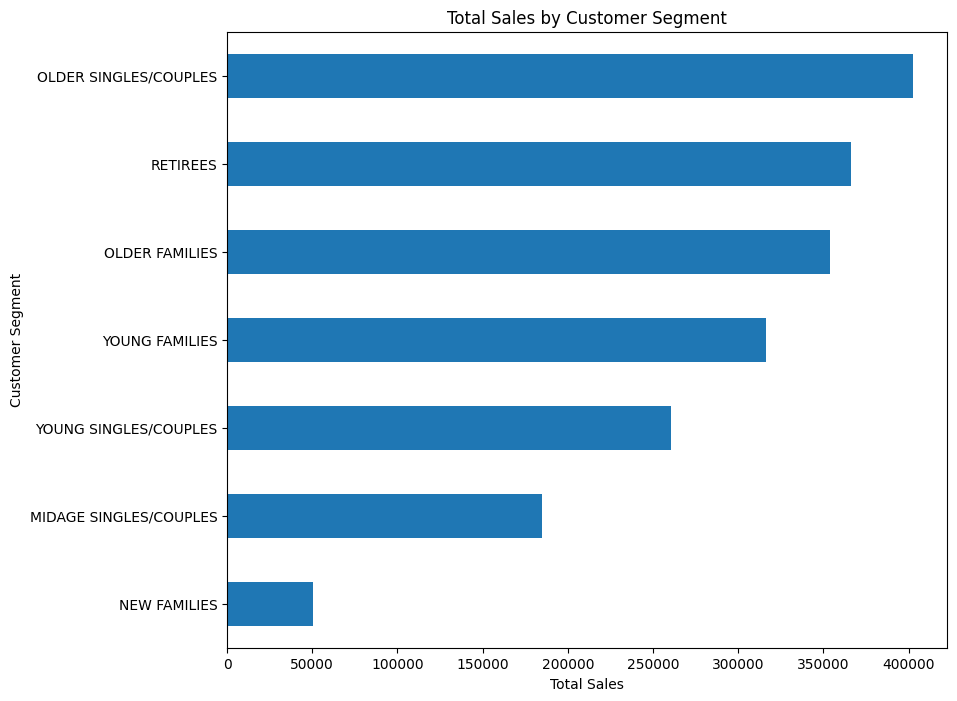

In [79]:
sales_by_segment = data.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values()

plt.figure(figsize=(12,8))
sales_by_segment.plot(kind='barh')
plt.title("Total Sales by Customer Segment")
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")

plt.subplots_adjust(left=0.3)
plt.savefig("sales_by_segment.png",  bbox_inches='tight')
plt.show()

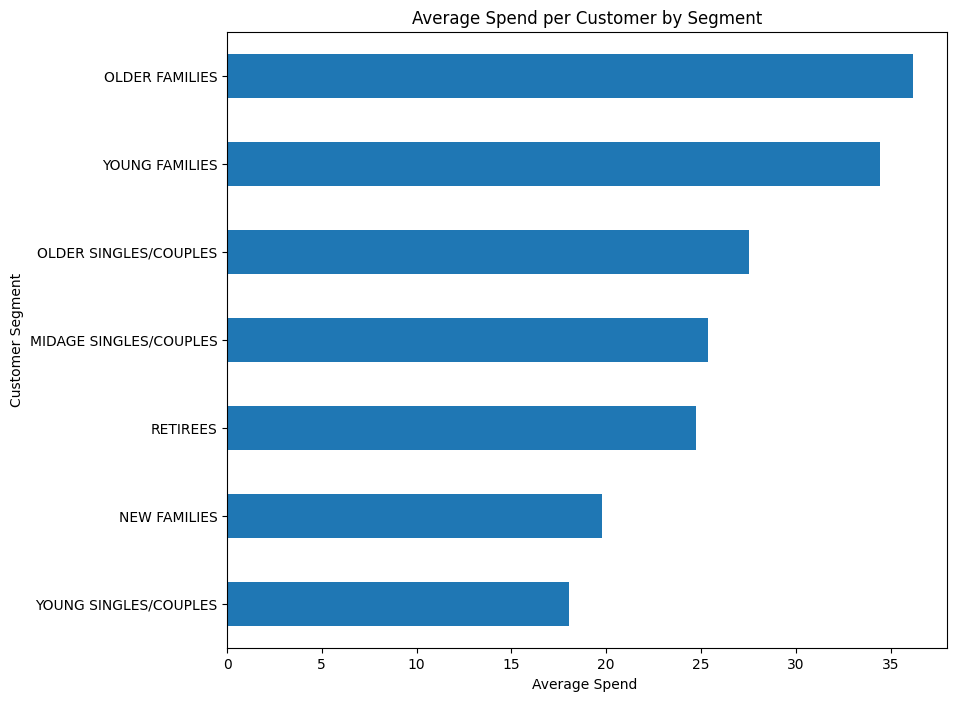

In [80]:
avg_spend_sorted = sales_per_coustomer['AVG_SPEND'].sort_values()

plt.figure(figsize=(12,8))
avg_spend_sorted.plot(kind='barh')

plt.title("Average Spend per Customer by Segment")
plt.xlabel("Average Spend ")
plt.ylabel("Customer Segment")

plt.subplots_adjust(left=0.3)
plt.savefig("avg_spend_by_segment.png",  bbox_inches='tight')
plt.show()

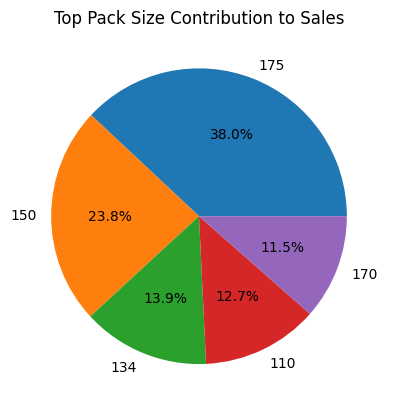

In [81]:
# kind='pie' → Pie chart , autopct='%1.1f%%' → shows percentage

pack_sales = data.groupby('PACK_SIZE')['TOT_SALES'].sum()

top_packs = pack_sales.sort_values(ascending=False).head(5)

plt.Figure()
top_packs.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top Pack Size Contribution to Sales")
plt.ylabel("")  # removes extra label

plt.savefig("pack_size_pie.png")
plt.show()

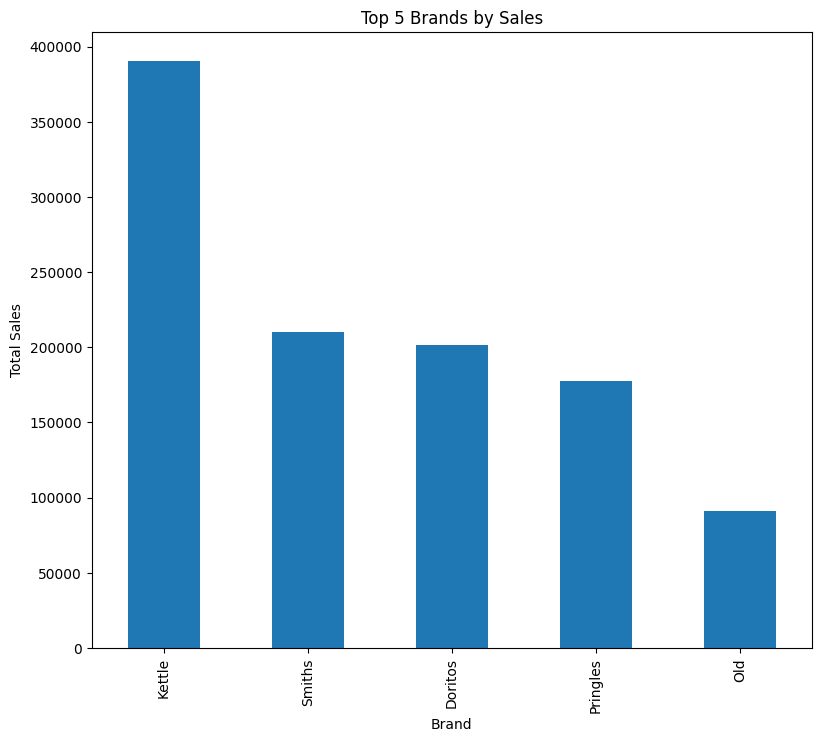

In [82]:
brand_sales = data.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(12,8))
brand_sales.plot(kind='bar')

plt.title("Top 5 Brands by Sales")
plt.xlabel("Brand")
plt.ylabel("Total Sales")

plt.subplots_adjust(left=0.3)
plt.savefig("top_brands.png",  bbox_inches='tight')
plt.show()